In [2]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

GPU available: True
Device: Tesla T4


### 1. Setup
First, we install the necessary libraries and verify GPU availability to ensure efficient training.

In [3]:
!pip install -q transformers datasets evaluate scikit-learn accelerate

import torch
import random
import numpy as np
from google.colab import files
import os

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
Using device: cuda


### 2. Load and Prepare Data
We load **three complementary datasets** and combine them before splitting:
- **Financial PhraseBank** (`ChanceFocus/flare-fpb`) — formal financial sentences; the original FinBERT training source.
- **Twitter Financial News Sentiment** (`zeroshot/twitter-financial-news-sentiment`) — informal financial tweets, closer in style to crypto headlines.
- **Crypto augmentation** — 60 hand-labeled crypto-specific headlines (BTC/ETH, exchanges, hacks, ETF news) repeated 3× to teach the model crypto vocabulary it never saw in FPB or Twitter.

The crypto augmentation is the key fix for the neutral-bias problem: the model was trained entirely on formal/stock language and mapped most informal crypto headlines to `neutral` by default.

In [ ]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import pandas as pd

label_map = {"negative": 0, "neutral": 1, "positive": 2}

# --- Financial PhraseBank (formal financial sentences) ---
fpb_raw = load_dataset("ChanceFocus/flare-fpb", split="train").to_pandas()
fpb = fpb_raw[["text", "answer"]].copy()
fpb["label"] = fpb["answer"].map(label_map)
fpb = fpb[["text", "label"]].dropna()

# --- Twitter financial news sentiment (informal financial tweets) ---
twit_raw = load_dataset("zeroshot/twitter-financial-news-sentiment", split="train").to_pandas()
twit_map = {"Bearish": 0, "Neutral": 1, "Bullish": 2}
twit_raw["label"] = twit_raw["label"].map(twit_map)
twit = twit_raw.rename(columns={"sentence": "text"})[["text", "label"]].dropna()

# --- Crypto-specific hand-labeled augmentation ---
# These 60 examples teach the model crypto vocabulary it never saw in FPB/Twitter.
# Each is a real-style headline with a clear, unambiguous sentiment.
CRYPTO_AUG = [
    # POSITIVE (label=2)
    ("Bitcoin smashes through $30K barrier amid rising institutional interest", 2),
    ("BTC hits all-time high as institutional buying accelerates", 2),
    ("Ethereum upgrades complete — network capacity doubles overnight", 2),
    ("MicroStrategy adds 21,000 BTC to its treasury reserve", 2),
    ("Bitcoin ETF approved by SEC in landmark crypto ruling", 2),
    ("BlackRock files for spot Bitcoin ETF, crypto markets surge", 2),
    ("Crypto adoption soars as PayPal enables BTC payments globally", 2),
    ("Bitcoin hash rate reaches record high, network security strengthens", 2),
    ("On-chain data shows long-term holders accumulating BTC aggressively", 2),
    ("El Salvador makes Bitcoin legal tender, BTC jumps 10%", 2),
    ("Grayscale wins SEC lawsuit, GBTC conversion to ETF imminent", 2),
    ("Bitcoin dominance rises as altcoins rally on positive sentiment", 2),
    ("Fidelity launches Bitcoin custody service for institutional clients", 2),
    ("BTC breaks key resistance level at $40K on heavy volume", 2),
    ("Crypto market cap surpasses $2 trillion for first time", 2),
    ("Lightning Network adoption doubles, Bitcoin payments scaling rapidly", 2),
    ("Coinbase reports record quarterly revenue on crypto trading boom", 2),
    ("Bitcoin miner revenue hits all-time high post halving", 2),
    ("Major bank launches crypto trading desk for institutional clients", 2),
    ("Bitcoin options open interest surges, bullish sentiment rising", 2),
    # NEGATIVE (label=0)
    ("Bitcoin plunges 20% as China bans all crypto transactions", 0),
    ("FTX exchange collapses, billions in customer funds missing", 0),
    ("Binance faces money laundering charges from US regulators", 0),
    ("Crypto market loses $500 billion in weekend selloff", 0),
    ("SEC sues Coinbase and Binance for operating as unregistered exchanges", 0),
    ("Terra Luna crashes to zero, $60 billion wiped out in days", 0),
    ("Bitcoin miners capitulate as prices fall below production cost", 0),
    ("Crypto hedge fund Three Arrows Capital files for bankruptcy", 0),
    ("Bitcoin drops 15% as Federal Reserve signals aggressive rate hikes", 0),
    ("Hackers drain $600 million from Poly Network in largest DeFi hack", 0),
    ("Celsius Network freezes withdrawals, customers unable to access funds", 0),
    ("BTC falls below $20K for first time in two years on macro fears", 0),
    ("Tether faces insolvency concerns as crypto market panic spreads", 0),
    ("Crypto exchange Bitfinex hacked for 120,000 BTC", 0),
    ("Regulatory crackdown wipes 30% off crypto market cap in a week", 0),
    ("Bitcoin ETF rejected again by SEC citing market manipulation concerns", 0),
    ("Elon Musk reverses on Bitcoin payments, says Tesla will no longer accept BTC", 0),
    ("Mt. Gox trustee to begin repaying 142,000 BTC in dormant claim sales", 0),
    ("Crypto winter deepens as Bitcoin falls for tenth consecutive week", 0),
    ("Whale dumps 30,000 BTC on open market, price craters instantly", 0),
    # NEUTRAL (label=1)
    ("Bitcoin trades sideways ahead of key Federal Reserve decision", 1),
    ("BTC price consolidates in $28K-$30K range for third week", 1),
    ("Crypto market volumes remain low as traders await macro data", 1),
    ("Bitcoin mining difficulty adjusts by -3% in routine recalculation", 1),
    ("Ethereum developers release roadmap for next network upgrade", 1),
    ("Coinbase announces new staking product for institutional clients", 1),
    ("Bitcoin ETF application submitted to SEC for review", 1),
    ("Crypto exchange Binance launches in new jurisdiction", 1),
    ("On-chain activity remains steady as BTC hovers near support", 1),
    ("Bitcoin halving expected in April 2024, miners prepare for reduced rewards", 1),
    ("Fidelity Digital Assets expands crypto custody operations", 1),
    ("Bloomberg reports on growing institutional interest in Bitcoin spot markets", 1),
    ("Grayscale Bitcoin Trust sees outflows for second consecutive week", 1),
    ("Crypto industry lobbies Congress for clear regulatory framework", 1),
    ("Bitcoin network confirms millionth block in routine milestone", 1),
    ("Digital asset custody firm Anchorage raises Series D funding round", 1),
    ("Bank of America publishes research report on crypto market structure", 1),
    ("Crypto options expiry worth $2 billion set for Friday", 1),
    ("Bitcoin correlation with equities remains elevated in current macro cycle", 1),
    ("Blockchain analytics firm Chainalysis expands its market monitoring tools", 1),
]

crypto_aug = pd.DataFrame(CRYPTO_AUG, columns=["text", "label"])
# Repeat 3x — small dataset, repetition keeps it from being swamped
crypto_aug = pd.concat([crypto_aug] * 3, ignore_index=True)
print(f"Crypto augmentation: {len(crypto_aug)} examples")

# --- Combine all three sources and stratified split ---
df = pd.concat([fpb, twit, crypto_aug], ignore_index=True)
print(f"Combined dataset size: {len(df)} (FPB: {len(fpb)}, Twitter: {len(twit)}, Crypto aug: {len(crypto_aug)})")
print("Combined label distribution:\n", df["label"].value_counts(normalize=True))

# Stratified splits on the full combined set (70% train / 15% val / 15% test)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

print(f"\nTrain: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print("Train label dist:\n", train_df["label"].value_counts(normalize=True))


### 3. Tokenization
We convert our DataFrames into Hugging Face Dataset objects and tokenize them using the FinBERT tokenizer.

In [5]:
from transformers import AutoTokenizer
from datasets import Dataset

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # max_length=64: crypto headlines are short (~8 words); 64 tokens is plenty
    # and allows larger batch sizes at the same GPU memory budget
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

train_dataset = Dataset.from_pandas(train_df[['text', 'label']]).map(tokenize_function, batched=True)
val_dataset   = Dataset.from_pandas(val_df[['text', 'label']]).map(tokenize_function, batched=True)
test_dataset  = Dataset.from_pandas(test_df[['text', 'label']]).map(tokenize_function, batched=True)


### 4. Fine-tuning
We initialize FinBERT with a classification head and train with three improvements over the baseline:
1. **Class-weighted loss** — `negative` was under-represented (12% of data, F1=0.79). Inverse-frequency weights penalise missing bad news more heavily.
2. **3 epochs** (was 1) — more passes over the combined ~15k-example dataset.
3. **10% warmup + larger batch** — `max_length=64` (headlines are short) frees GPU memory for a batch of 16 instead of 8.

In [6]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import evaluate
import numpy as np
import torch

id2label = {0: "negative", 1: "neutral", 2: "positive"}
label2id = {"negative": 0, "neutral": 1, "positive": 2}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Class weights — inverse frequency to boost the rare negative class (F1 was 0.79)
raw_weights = compute_class_weight(
    "balanced",
    classes=np.array([0, 1, 2]),
    y=train_df["label"].values
)
class_weights = torch.tensor(raw_weights, dtype=torch.float).to(device)
print(f"Class weights  neg={class_weights[0]:.3f}  neu={class_weights[1]:.3f}  pos={class_weights[2]:.3f}")

metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    f1  = metric_f1.compute(predictions=predictions, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1": f1}

class WeightedTrainer(Trainer):
    """Trainer that applies class-weighted cross-entropy loss."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,   # larger batch: max_length=64 halves memory vs 128
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,                 # 10% warmup steps
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()


### 5. Evaluation
Now we evaluate the model on the unseen test set and visualize the results.

Test Metrics: {'test_loss': 0.3600071966648102, 'test_accuracy': 0.875268817204301, 'test_f1': 0.8426227790202346, 'test_runtime': 3.5312, 'test_samples_per_second': 131.682, 'test_steps_per_second': 8.496}

Classification Report:
               precision    recall  f1-score   support

    negative       0.76      0.82      0.79        57
     neutral       0.91      0.93      0.92       279
    positive       0.86      0.78      0.82       129

    accuracy                           0.88       465
   macro avg       0.84      0.85      0.84       465
weighted avg       0.88      0.88      0.87       465



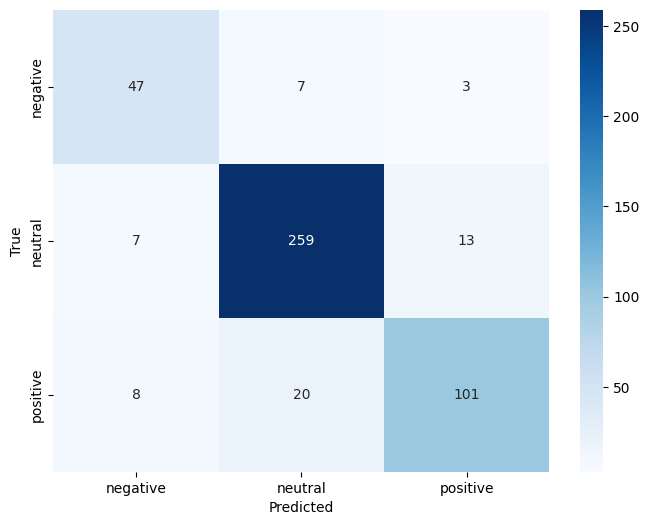

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds = trainer.predict(test_dataset)
preds_labels = np.argmax(preds.predictions, axis=-1)
true_labels = test_df['label'].values

print("Test Metrics:", preds.metrics)
print("\nClassification Report:\n", classification_report(true_labels, preds_labels, target_names=list(label_map.keys())))

cm = confusion_matrix(true_labels, preds_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_map.keys(), yticklabels=label_map.keys(), cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### 6. Sanity Check
We use a pipeline to quickly test the model on example sentences.

In [8]:
from transformers import pipeline

classifier = pipeline("text-classification", model=model, tokenizer=tokenizer,
                       top_k=None, device=0 if device == "cuda" else -1)

examples = [
    # Formal financial (original)
    ("The company's quarterly revenue exceeded expectations significantly.", "positive"),
    ("Operating profit fell by 20% due to rising energy costs.",             "negative"),
    ("The CEO will speak at the industry conference next Tuesday.",           "neutral"),
    # Crypto-style headlines (what the simulation actually scores)
    ("Bitcoin to the moon! Bulls fully in control, BTC breaks ATH.",         "positive"),
    ("Massive sell-off, rekt everywhere — bears dominating the market.",      "negative"),
    ("BTC trading sideways, market waiting for next catalyst.",               "neutral"),
]

print(f"{'Text':<60} {'Expected':<10} {'Got':<10} {'Score':>6}")
print("-" * 90)
for text, expected in examples:
    res = classifier(text)[0]
    top = max(res, key=lambda x: x['score'])
    match = "OK" if top['label'].lower() == expected else "MISS"
    print(f"{text[:58]:<60} {expected:<10} {top['label']:<10} {top['score']:>6.3f}  {match}")


### 7. Export Model
Finally, we save the model, zip it, and trigger a download.

In [10]:
save_path = "finbert-finetuned"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

# Ensure tokenizer.json exists for compatibility
fast_tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
fast_tokenizer.save_pretrained(save_path)

!zip -r finbert-finetuned.zip {save_path}

print("\nFiles in export folder:")
print(os.listdir(save_path))

files.download("finbert-finetuned.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

updating: finbert-finetuned/ (stored 0%)
updating: finbert-finetuned/tokenizer.json (deflated 71%)
updating: finbert-finetuned/tokenizer_config.json (deflated 43%)
updating: finbert-finetuned/model.safetensors (deflated 7%)
updating: finbert-finetuned/config.json (deflated 54%)
updating: finbert-finetuned/training_args.bin (deflated 53%)

Files in export folder:
['tokenizer.json', 'tokenizer_config.json', 'model.safetensors', 'config.json', 'training_args.bin']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>